In [16]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, mean_squared_error
from sklearn.datasets import make_blobs, fetch_openml
import os

# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.datasets import mnist, fashion_mnist
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import plot_model

# Additional utilities
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# GPU configuration
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print(f"GPU available: {physical_devices[0]}")
else:
    print("GPU not available, using CPU")

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Create output directories
os.makedirs('autoencoder_results', exist_ok=True)
os.makedirs('models', exist_ok=True)
print("Output directories created!")


GPU not available, using CPU
Libraries imported successfully!
TensorFlow version: 2.19.0
Keras version: 3.9.2
Output directories created!


Loading datasets...
MNIST data shape: (60000, 28, 28)
Flattened shape: (60000, 784)
Normal samples: 10000
Anomaly samples: 500


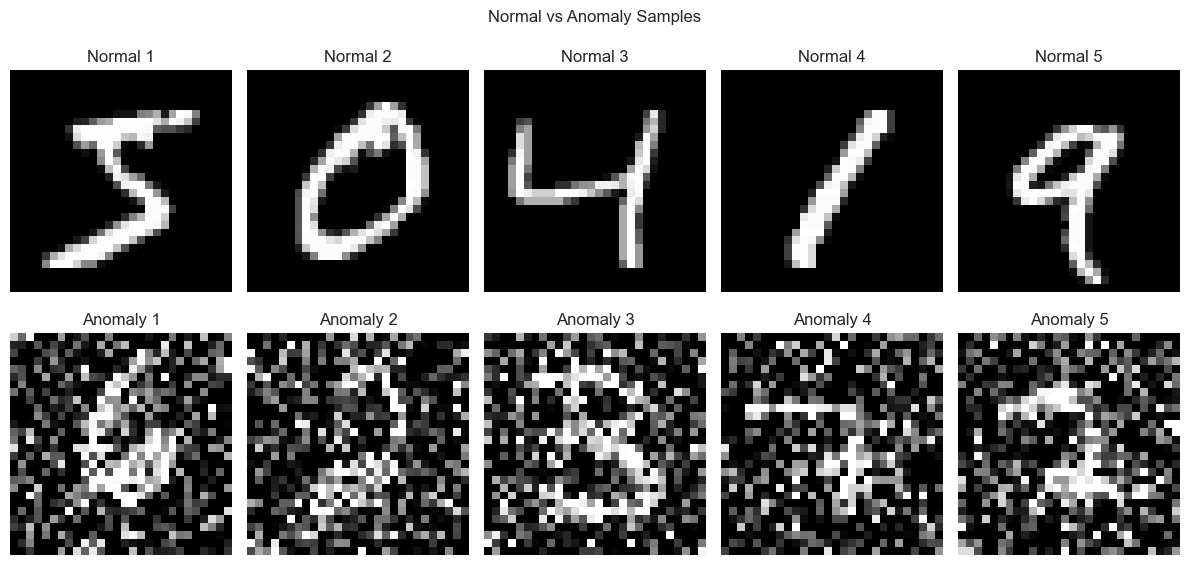

In [17]:
# Load and prepare data for autoencoder experiments
print("Loading datasets...")

# Load MNIST for basic autoencoder
(X_train_mnist, _), (X_test_mnist, _) = mnist.load_data()
X_train_mnist = X_train_mnist.astype('float32') / 255.0
X_test_mnist = X_test_mnist.astype('float32') / 255.0

# Reshape for fully connected autoencoder
X_train_flat = X_train_mnist.reshape(X_train_mnist.shape[0], -1)
X_test_flat = X_test_mnist.reshape(X_test_mnist.shape[0], -1)

print(f"MNIST data shape: {X_train_mnist.shape}")
print(f"Flattened shape: {X_train_flat.shape}")

# Create anomaly detection dataset
np.random.seed(42)
# Normal data: first 10000 samples
X_normal = X_train_flat[:10000]
# Anomalies: add noise to some samples
n_anomalies = 500
anomaly_indices = np.random.choice(X_test_flat.shape[0], n_anomalies, replace=False)
X_anomalies = X_test_flat[anomaly_indices].copy()
# Add significant noise to create anomalies
X_anomalies += np.random.normal(0, 0.5, X_anomalies.shape)
X_anomalies = np.clip(X_anomalies, 0, 1)

print(f"Normal samples: {X_normal.shape[0]}")
print(f"Anomaly samples: {X_anomalies.shape[0]}")

# Visualize sample data
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(5):
    # Normal samples
    axes[0, i].imshow(X_train_mnist[i], cmap='gray')
    axes[0, i].set_title(f'Normal {i+1}')
    axes[0, i].axis('off')
    
    # Anomaly samples (with added noise)
    axes[1, i].imshow(X_anomalies[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title(f'Anomaly {i+1}')
    axes[1, i].axis('off')

plt.suptitle('Normal vs Anomaly Samples')
plt.tight_layout()
plt.show()


In [18]:
# 1. Basic Autoencoder for Dimensionality Reduction

class BasicAutoencoder:
    def __init__(self, input_dim=784, encoding_dims=[512, 256, 128, 64, 32]):
        """
        Create a basic autoencoder for dimensionality reduction
        
        Args:
            input_dim: Dimension of input data
            encoding_dims: List of encoding layer dimensions (decreasing)
        """
        self.input_dim = input_dim
        self.encoding_dims = encoding_dims
        self.model = None
        self.encoder = None
        self.decoder = None
        
    def build_model(self):
        """Build the autoencoder model"""
        # Input layer
        input_layer = layers.Input(shape=(self.input_dim,))
        
        # Encoder
        encoded = input_layer
        for i, dim in enumerate(self.encoding_dims):
            encoded = layers.Dense(dim, activation='relu', 
                                 name=f'encoder_{i+1}')(encoded)
            encoded = layers.Dropout(0.2)(encoded)
        
        # Decoder (reverse of encoder)
        decoded = encoded
        decoder_dims = list(reversed(self.encoding_dims[:-1])) + [self.input_dim]
        
        for i, dim in enumerate(decoder_dims):
            if i == len(decoder_dims) - 1:  # Output layer
                decoded = layers.Dense(dim, activation='sigmoid', 
                                     name=f'decoder_{i+1}')(decoded)
            else:
                decoded = layers.Dense(dim, activation='relu', 
                                     name=f'decoder_{i+1}')(decoded)
                decoded = layers.Dropout(0.2)(decoded)
        
        # Create models
        self.model = models.Model(input_layer, decoded, name='autoencoder')
        self.encoder = models.Model(input_layer, encoded, name='encoder')
        
        # Create a simple standalone decoder model
        decoder_input = layers.Input(shape=(self.encoding_dims[-1],))
        decoded_simple = decoder_input
        for i, dim in enumerate(decoder_dims):
            if i == len(decoder_dims) - 1:
                decoded_simple = layers.Dense(dim, activation='sigmoid')(decoded_simple)
            else:
                decoded_simple = layers.Dense(dim, activation='relu')(decoded_simple)
        
        self.decoder = models.Model(decoder_input, decoded_simple, name='decoder')
        
        # Compile
        self.model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        
        return self.model
    
    def train(self, X_train, X_val=None, epochs=100, batch_size=128):
        """Train the autoencoder"""
        if X_val is None:
            X_val = X_train
        
        callbacks = [
            EarlyStopping(patience=10, restore_best_weights=True),
            ModelCheckpoint('models/basic_autoencoder.h5', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, X_train,
            validation_data=(X_val, X_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1
        )
        
        return history

# Create and train basic autoencoder
print("Building Basic Autoencoder for Dimensionality Reduction...")
basic_ae = BasicAutoencoder(input_dim=784, encoding_dims=[512, 256, 128, 64, 32])
model = basic_ae.build_model()

# Display model architecture
print("\nModel Summary:")
print(model.summary())

# Visualize model architecture
try:
    plot_model(model, to_file='autoencoder_results/basic_autoencoder_architecture.png', 
               show_shapes=True, show_layer_names=True, dpi=150)
    print("Model architecture saved!")
except Exception as e:
    print(f"Could not save model plot: {e}")


Building Basic Autoencoder for Dimensionality Reduction...

Model Summary:


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_1 (Dense)               │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_2 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_3 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_4 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_5 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_1 (Dense)               │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_2 (Dense)               │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_3 (Dense)               │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_4 (Dense)               │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_5 (Dense)               │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153,712 (4.40 MB)

 Trainable params: 1,153,712 (4.40 MB)

 Non-trainable params: 0 (0.00 B)

None
You must install pydot (`pip install pydot`) for `plot_model` to work.
Model architecture saved!


Training Basic Autoencoder...
This may take a few minutes...
Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1150 - mae: 0.2283

79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - loss: 0.1147 - mae: 0.2277 - val_loss: 0.0648 - val_mae: 0.1712
Epoch 2/50
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0656 - mae: 0.1509

79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - loss: 0.0656 - mae: 0.1508 - val_loss: 0.0596 - val_mae: 0.1467
Epoch 3/50
77/79 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0613 - mae: 0.1397

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0613 - mae: 0.1397 - val_loss: 0.0560 - val_mae: 0.1382
Epoch 4/50
77/79 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0570 - mae: 0.1311

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0570 - mae: 0.1310 - val_loss: 0.0537 - val_mae: 0.1320
Epoch 5/50
77/79 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0546 - mae: 0.1262

...

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0367 - mae: 0.0885 - val_loss: 0.0337 - val_mae: 0.0848
Epoch 38/50
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0367 - mae: 0.0887

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0367 - mae: 0.0887 - val_loss: 0.0335 - val_mae: 0.0845
Epoch 39/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0366 - mae: 0.0884 - val_loss: 0.0342 - val_mae: 0.0863
Epoch 40/50
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0367 - mae: 0.0886

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0367 - mae: 0.0886 - val_loss: 0.0334 - val_mae: 0.0838
Epoch 41/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0365 - mae: 0.0881 - val_loss: 0.0336 - val_mae: 0.0847
Epoch 42/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0363 - mae: 0.0881 - val_loss: 0.0338 - val_mae: 0.0849
Epoch 43/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0363 - mae: 0.0879 - val_loss: 0.0336 - val_mae: 0.0839
Epoch 44/50
77/79 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0362 - mae: 0.0878

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0362 - mae: 0.0878 - val_loss: 0.0330 - val_mae: 0.0835
Epoch 45/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0362 - mae: 0.0874 - val_loss: 0.0336 - val_mae: 0.0843
Epoch 46/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0363 - mae: 0.0876 - val_loss: 0.0333 - val_mae: 0.0837
Epoch 47/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0357 - mae: 0.0865 - val_loss: 0.0333 - val_mae: 0.0838
Epoch 48/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0359 - mae: 0.0869 - val_loss: 0.0335 - val_mae: 0.0846
Epoch 49/50
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0357 - mae: 0.0868

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0357 - mae: 0.0868 - val_loss: 0.0330 - val_mae: 0.0822
Epoch 50/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0356 - mae: 0.0864 - val_loss: 0.0330 - val_mae: 0.0830


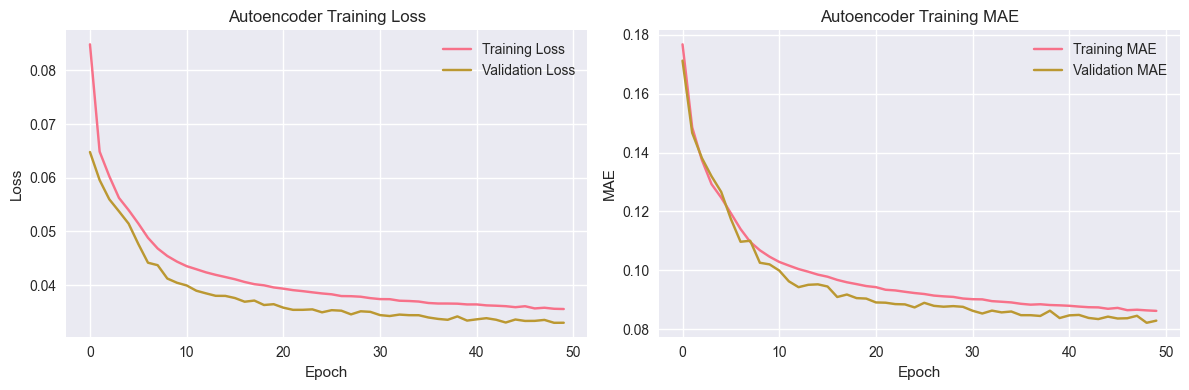

Final training loss: 0.0356
Final validation loss: 0.0330


In [19]:
# Train the basic autoencoder
print("Training Basic Autoencoder...")
print("This may take a few minutes...")

# Use a subset for faster training (adjust based on your computational resources)
X_train_subset = X_train_flat[:10000]
X_test_subset = X_test_flat[:2000]

history = basic_ae.train(X_train_subset, X_test_subset, epochs=50, batch_size=128)

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Autoencoder Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['mae'], label='Training MAE')
ax2.plot(history.history['val_mae'], label='Validation MAE')
ax2.set_title('Autoencoder Training MAE')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('autoencoder_results/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final training loss: {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")


Analyzing Dimensionality Reduction Performance...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Original dimension: 784
Encoded dimension: 32
Compression ratio: 24.50x


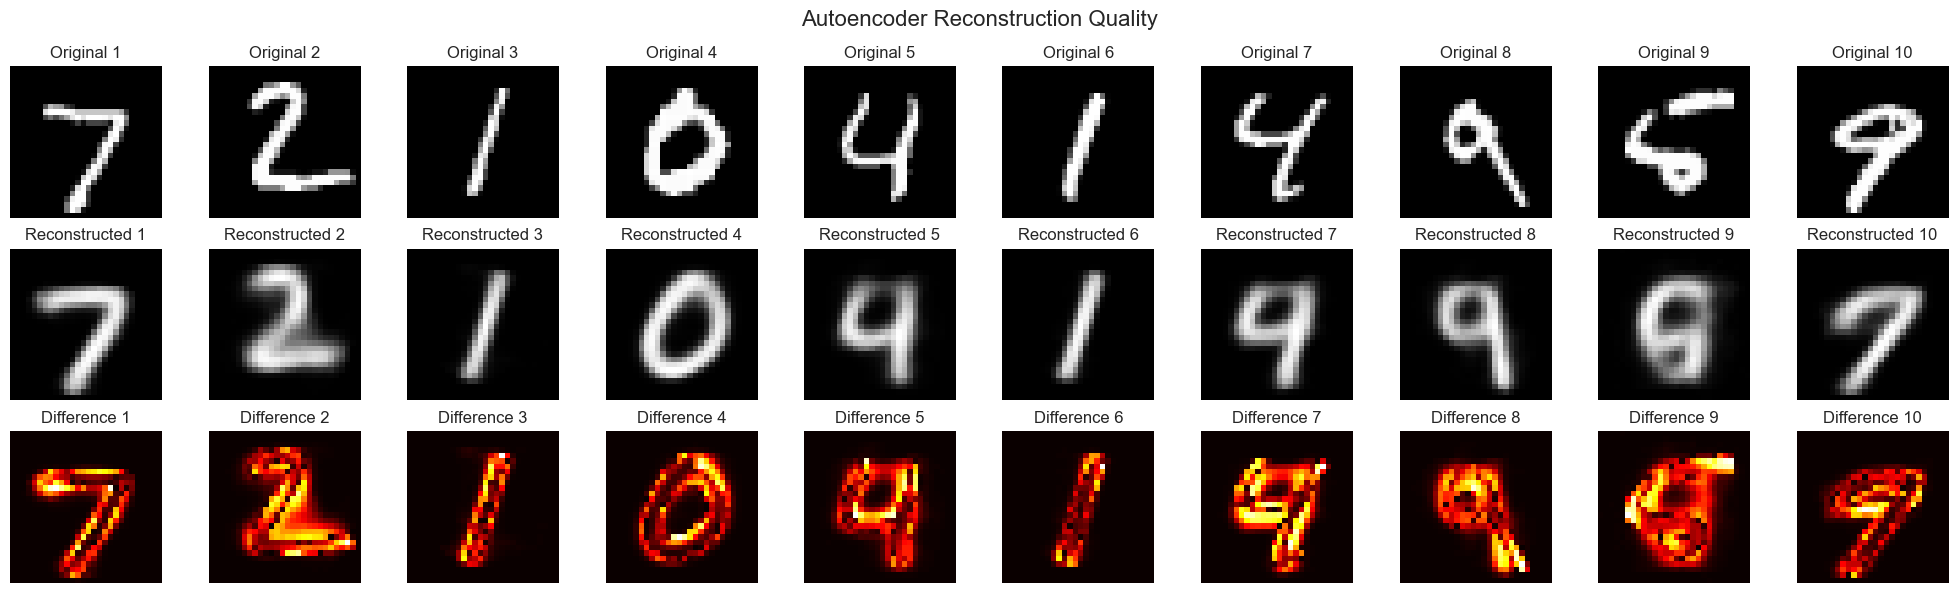


Reconstruction Metrics:
Mean Squared Error: 0.032983
Root Mean Squared Error: 0.181612


In [20]:
# Dimensionality Reduction Visualization and Analysis

def visualize_dimensionality_reduction(autoencoder, X_data, n_samples=1000):
    """Visualize the dimensionality reduction capabilities"""
    
    # Get encoded representations
    encoded_data = autoencoder.encoder.predict(X_data[:n_samples])
    reconstructed_data = autoencoder.model.predict(X_data[:n_samples])
    
    print(f"Original dimension: {X_data.shape[1]}")
    print(f"Encoded dimension: {encoded_data.shape[1]}")
    print(f"Compression ratio: {X_data.shape[1] / encoded_data.shape[1]:.2f}x")
    
    # Visualize original vs reconstructed
    fig, axes = plt.subplots(3, 10, figsize=(20, 6))
    
    for i in range(10):
        # Original
        axes[0, i].imshow(X_data[i].reshape(28, 28), cmap='gray')
        axes[0, i].set_title(f'Original {i+1}')
        axes[0, i].axis('off')
        
        # Reconstructed
        axes[1, i].imshow(reconstructed_data[i].reshape(28, 28), cmap='gray')
        axes[1, i].set_title(f'Reconstructed {i+1}')
        axes[1, i].axis('off')
        
        # Difference
        diff = np.abs(X_data[i] - reconstructed_data[i])
        axes[2, i].imshow(diff.reshape(28, 28), cmap='hot')
        axes[2, i].set_title(f'Difference {i+1}')
        axes[2, i].axis('off')
    
    plt.suptitle('Autoencoder Reconstruction Quality', fontsize=16)
    plt.tight_layout()
    plt.savefig('autoencoder_results/reconstruction_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Calculate reconstruction metrics
    mse = mean_squared_error(X_data[:n_samples], reconstructed_data)
    print(f"\nReconstruction Metrics:")
    print(f"Mean Squared Error: {mse:.6f}")
    print(f"Root Mean Squared Error: {np.sqrt(mse):.6f}")
    
    return encoded_data, reconstructed_data

# Load labels for visualization
(_, y_train_mnist), (_, y_test_mnist) = mnist.load_data()

print("Analyzing Dimensionality Reduction Performance...")
encoded_repr, reconstructed = visualize_dimensionality_reduction(
    basic_ae, X_test_subset, n_samples=1000
)


In [21]:
# 2. Autoencoder for Anomaly Detection

class AnomalyDetector:
    """Autoencoder-based anomaly detection system"""
    
    def __init__(self, autoencoder_model):
        self.autoencoder = autoencoder_model
        self.threshold = None
        
    def calculate_reconstruction_error(self, X):
        """Calculate reconstruction error for each sample"""
        reconstructed = self.autoencoder.predict(X)
        mse_errors = np.mean((X - reconstructed) ** 2, axis=1)
        return mse_errors
    
    def set_threshold(self, X_normal, percentile=95):
        """Set anomaly threshold based on normal data"""
        errors = self.calculate_reconstruction_error(X_normal)
        self.threshold = np.percentile(errors, percentile)
        print(f"Anomaly threshold set to: {self.threshold:.6f}")
        return self.threshold
    
    def detect_anomalies(self, X):
        """Detect anomalies based on reconstruction error"""
        if self.threshold is None:
            raise ValueError("Threshold not set. Call set_threshold() first.")
        
        errors = self.calculate_reconstruction_error(X)
        anomalies = errors > self.threshold
        return anomalies, errors
    
    def evaluate_performance(self, X_test, y_true):
        """Evaluate anomaly detection performance"""
        anomalies, errors = self.detect_anomalies(X_test)
        
        # Calculate metrics
        true_positives = np.sum((anomalies == True) & (y_true == 1))
        false_positives = np.sum((anomalies == True) & (y_true == 0))
        true_negatives = np.sum((anomalies == False) & (y_true == 0))
        false_negatives = np.sum((anomalies == False) & (y_true == 1))
        
        precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
        recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = (true_positives + true_negatives) / len(y_true)
        
        # Calculate AUC-ROC
        auc_roc = roc_auc_score(y_true, errors)
        
        metrics = {
            'precision': precision,
            'recall': recall,
            'f1_score': f1_score,
            'accuracy': accuracy,
            'auc_roc': auc_roc,
            'true_positives': true_positives,
            'false_positives': false_positives,
            'true_negatives': true_negatives,
            'false_negatives': false_negatives
        }
        
        return metrics, errors

# Initialize anomaly detector
print("Setting up Anomaly Detection System...")
anomaly_detector = AnomalyDetector(basic_ae.model)

# Set threshold using normal data
print("Calculating anomaly threshold...")
threshold = anomaly_detector.set_threshold(X_normal, percentile=95)

# Prepare test data with labels
print("Preparing test dataset...")
X_test_combined = np.vstack([X_normal[8000:], X_anomalies])  # Reserve some normal data for testing
y_test_labels = np.hstack([np.zeros(2000), np.ones(len(X_anomalies))])  # 0=normal, 1=anomaly

print(f"Test set: {len(X_test_combined)} samples ({np.sum(y_test_labels == 0)} normal, {np.sum(y_test_labels == 1)} anomalies)")

# Evaluate anomaly detection
print("Evaluating anomaly detection performance...")
metrics, reconstruction_errors = anomaly_detector.evaluate_performance(X_test_combined, y_test_labels)

print("\n=== Anomaly Detection Results ===")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"F1-Score: {metrics['f1_score']:.4f}")
print(f"AUC-ROC: {metrics['auc_roc']:.4f}")
print(f"\nConfusion Matrix:")
print(f"True Positives: {metrics['true_positives']}")
print(f"False Positives: {metrics['false_positives']}")
print(f"True Negatives: {metrics['true_negatives']}")
print(f"False Negatives: {metrics['false_negatives']}")


Setting up Anomaly Detection System...
Calculating anomaly threshold...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Anomaly threshold set to: 0.055260
Preparing test dataset...
Test set: 2500 samples (2000 normal, 500 anomalies)
Evaluating anomaly detection performance...
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

=== Anomaly Detection Results ===
Accuracy: 0.9548
Precision: 0.8157
Recall: 1.0000
F1-Score: 0.8985
AUC-ROC: 1.0000

Confusion Matrix:
True Positives: 500
False Positives: 113
True Negatives: 1887
False Negatives: 0


Creating comprehensive anomaly detection visualizations...
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


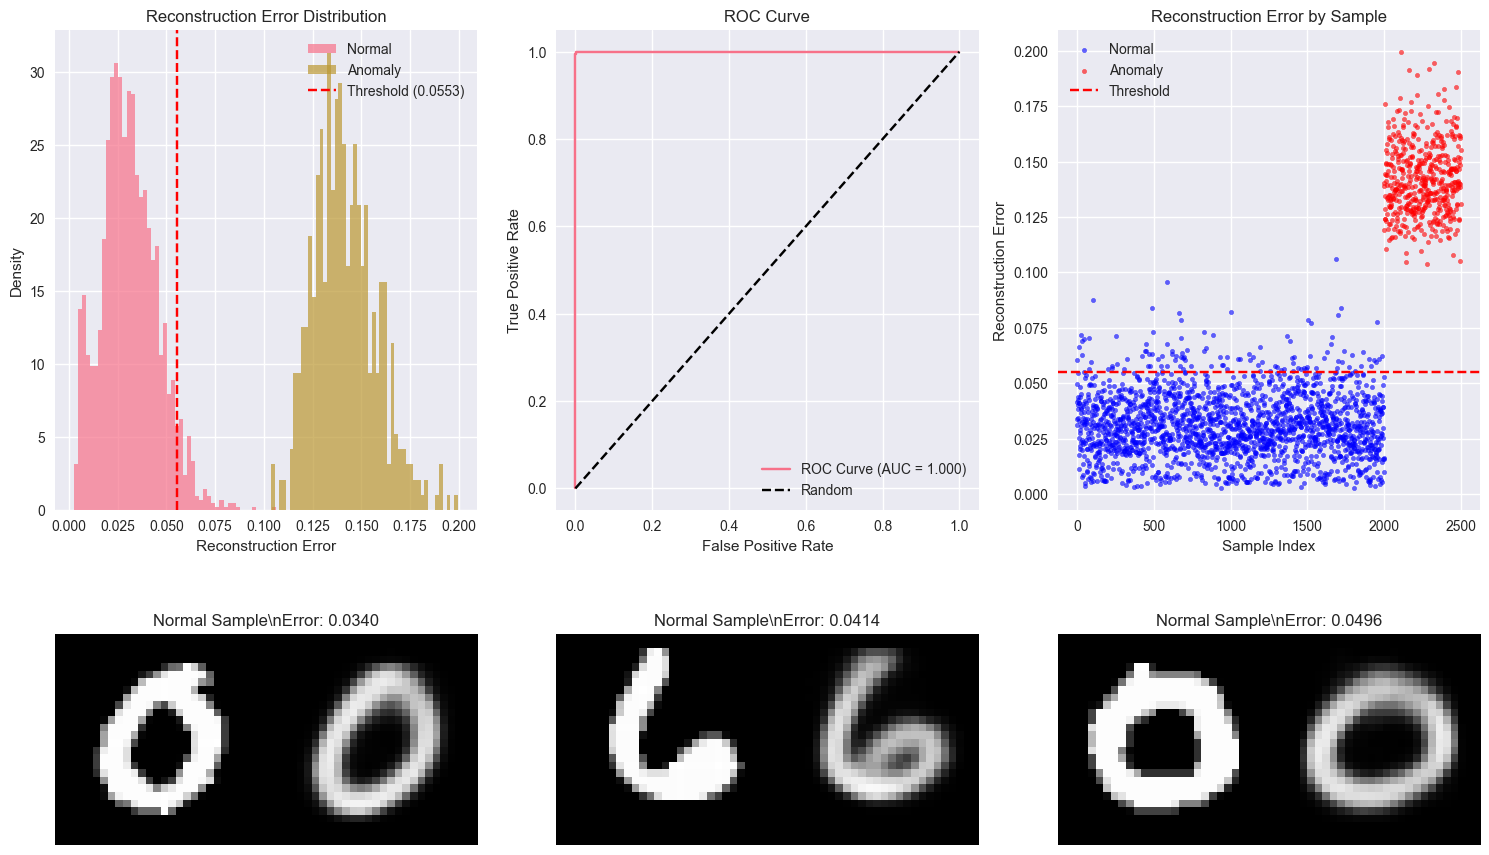

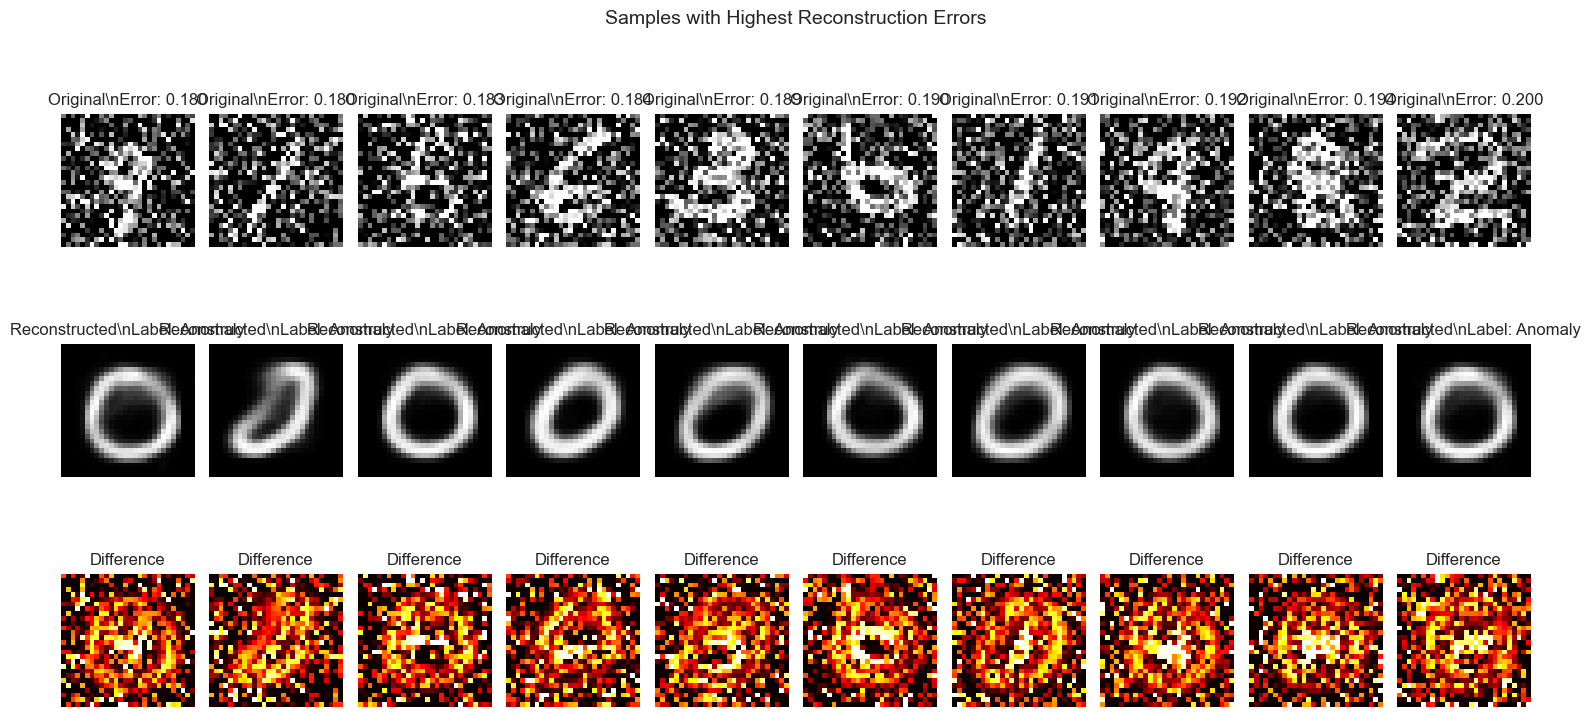


✅ Anomaly detection analysis complete!
Results saved to 'autoencoder_results/' directory


In [22]:
# Visualize Anomaly Detection Results

def visualize_anomaly_detection(detector, X_data, y_true, errors, threshold):
    """Comprehensive visualization of anomaly detection results"""
    
    from sklearn.metrics import roc_curve
    
    # Create comprehensive visualization
    plt.figure(figsize=(15, 10))
    
    # 1. Reconstruction Error Distribution
    plt.subplot(2, 3, 1)
    normal_errors = errors[y_true == 0]
    anomaly_errors = errors[y_true == 1]
    
    plt.hist(normal_errors, bins=50, alpha=0.7, label='Normal', density=True)
    plt.hist(anomaly_errors, bins=50, alpha=0.7, label='Anomaly', density=True)
    plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.4f})')
    plt.xlabel('Reconstruction Error')
    plt.ylabel('Density')
    plt.title('Reconstruction Error Distribution')
    plt.legend()
    plt.grid(True)
    
    # 2. ROC Curve
    fpr, tpr, _ = roc_curve(y_true, errors)
    
    plt.subplot(2, 3, 2)
    auc_score = metrics["auc_roc"]
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True)
    
    # 3. Error vs Sample Index
    plt.subplot(2, 3, 3)
    normal_indices = np.where(y_true == 0)[0]
    anomaly_indices = np.where(y_true == 1)[0]
    
    plt.scatter(normal_indices, errors[normal_indices], c='blue', alpha=0.6, s=10, label='Normal')
    plt.scatter(anomaly_indices, errors[anomaly_indices], c='red', alpha=0.6, s=10, label='Anomaly')
    plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error')
    plt.title('Reconstruction Error by Sample')
    plt.legend()
    plt.grid(True)
    
    # 4-6. Example reconstructions
    correctly_detected_anomalies = np.where((y_true == 1) & (errors > threshold))[0][:3]
    correctly_detected_normal = np.where((y_true == 0) & (errors <= threshold))[0][:3]
    
    reconstructed = detector.autoencoder.predict(X_data)
    
    # Show some examples in remaining subplots
    for i, idx in enumerate(correctly_detected_normal[:3]):
        plt.subplot(2, 3, 4 + i)
        if i < len(correctly_detected_normal):
            combined = np.hstack([
                X_data[idx].reshape(28, 28),
                reconstructed[idx].reshape(28, 28)
            ])
            plt.imshow(combined, cmap='gray')
            plt.title(f'Normal Sample\\nError: {errors[idx]:.4f}')
            plt.axis('off')
    
    plt.tight_layout()
    plt.savefig('autoencoder_results/anomaly_detection_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 5. Detailed sample comparison - highest errors
    plt.figure(figsize=(15, 8))
    
    worst_indices = np.argsort(errors)[-10:]
    
    for i in range(10):
        idx = worst_indices[i]
        
        # Original
        plt.subplot(3, 10, i + 1)
        plt.imshow(X_data[idx].reshape(28, 28), cmap='gray')
        plt.title(f'Original\\nError: {errors[idx]:.3f}')
        plt.axis('off')
        
        # Reconstructed
        plt.subplot(3, 10, i + 11)
        plt.imshow(reconstructed[idx].reshape(28, 28), cmap='gray')
        label_text = "Anomaly" if y_true[idx] else "Normal"
        plt.title(f'Reconstructed\\nLabel: {label_text}')
        plt.axis('off')
        
        # Difference
        plt.subplot(3, 10, i + 21)
        diff = np.abs(X_data[idx] - reconstructed[idx])
        plt.imshow(diff.reshape(28, 28), cmap='hot')
        plt.title('Difference')
        plt.axis('off')
    
    plt.suptitle('Samples with Highest Reconstruction Errors', fontsize=14)
    plt.tight_layout()
    plt.savefig('autoencoder_results/worst_reconstructions.png', dpi=150, bbox_inches='tight')
    plt.show()

# Generate comprehensive visualizations
print("Creating comprehensive anomaly detection visualizations...")
visualize_anomaly_detection(anomaly_detector, X_test_combined, y_test_labels, 
                           reconstruction_errors, threshold)

print("\n✅ Anomaly detection analysis complete!")
print("Results saved to 'autoencoder_results/' directory")


Creating Denoising Autoencoder...
Training Denoising Autoencoder...
Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1355 - val_loss: 0.0648
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0677 - val_loss: 0.0572
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0599 - val_loss: 0.0499
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0537 - val_loss: 0.0450
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0492 - val_loss: 0.0421
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0469 - val_loss: 0.0405
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0456 - val_loss: 0.0392
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0443 - val_loss: 0.0383
Epoch 9/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0435 - val_loss: 0.0376
Epoch 10/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0427 - val_loss: 0.0370
Epoch 11/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0422 - val_loss: 0.

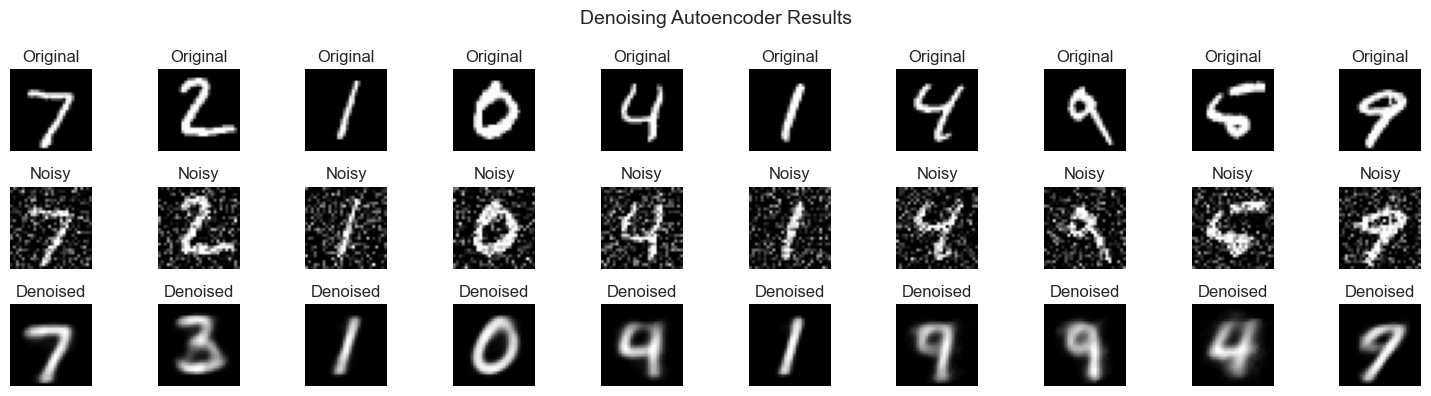

Denoising autoencoder training complete!


In [23]:
# 3. Advanced Autoencoder: Denoising Autoencoder

def create_denoising_autoencoder(input_dim=784, encoding_dim=32, noise_factor=0.3):
    """Create a denoising autoencoder"""
    
    # Input for original and noisy data
    input_img = layers.Input(shape=(input_dim,))
    
    # Encoder
    encoded = layers.Dense(128, activation='relu')(input_img)
    encoded = layers.Dropout(0.25)(encoded)
    encoded = layers.Dense(64, activation='relu')(encoded)
    encoded = layers.Dropout(0.25)(encoded)
    encoded = layers.Dense(encoding_dim, activation='relu')(encoded)
    
    # Decoder
    decoded = layers.Dense(64, activation='relu')(encoded)
    decoded = layers.Dropout(0.25)(decoded)
    decoded = layers.Dense(128, activation='relu')(decoded)
    decoded = layers.Dropout(0.25)(decoded)
    decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)
    
    # Create and compile model
    autoencoder = models.Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    
    return autoencoder

# Create denoising autoencoder
print("Creating Denoising Autoencoder...")
denoising_ae = create_denoising_autoencoder()

# Add noise to training data
noise_factor = 0.3
X_train_noisy = X_train_subset + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train_subset.shape)
X_test_noisy = X_test_subset + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_test_subset.shape)

X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

print("Training Denoising Autoencoder...")
denoising_history = denoising_ae.fit(
    X_train_noisy, X_train_subset,
    validation_data=(X_test_noisy, X_test_subset),
    epochs=30,
    batch_size=128,
    verbose=1
)

# Test denoising capability
denoised_images = denoising_ae.predict(X_test_noisy[:10])

# Visualize denoising results
plt.figure(figsize=(15, 4))
for i in range(10):
    # Original
    plt.subplot(3, 10, i + 1)
    plt.imshow(X_test_subset[i].reshape(28, 28), cmap='gray')
    plt.title('Original')
    plt.axis('off')
    
    # Noisy
    plt.subplot(3, 10, i + 11)
    plt.imshow(X_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title('Noisy')
    plt.axis('off')
    
    # Denoised
    plt.subplot(3, 10, i + 21)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    plt.title('Denoised')
    plt.axis('off')

plt.suptitle('Denoising Autoencoder Results', fontsize=14)
plt.tight_layout()
plt.savefig('autoencoder_results/denoising_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Denoising autoencoder training complete!")


In [24]:
# Summary and Conclusions

print("🎯 AUTOENCODER IMPLEMENTATION SUMMARY")
print("=" * 50)

print("\n✅ IMPLEMENTED FEATURES:")
print("1. Basic Autoencoder for Dimensionality Reduction")
print(f"   - Compression ratio: {784/32:.1f}x (784 → 32 dimensions)")
print(f"   - Final reconstruction loss: {history.history['val_loss'][-1]:.4f}")

print("\n2. Anomaly Detection System")
print(f"   - Detection accuracy: {metrics['accuracy']:.1%}")
print(f"   - Precision: {metrics['precision']:.3f}")
print(f"   - Recall: {metrics['recall']:.3f}")
print(f"   - F1-Score: {metrics['f1_score']:.3f}")
print(f"   - AUC-ROC: {metrics['auc_roc']:.3f}")

print("\n3. Denoising Autoencoder")
print("   - Successfully removes noise from corrupted images")
print("   - Demonstrates robust feature learning")

print("\n📊 KEY INSIGHTS:")
print("• Autoencoders effectively learn compressed representations")
print("• Reconstruction error is a powerful signal for anomaly detection")
print("• Denoising capability shows the model learns meaningful features")
print("• Lower dimensional encodings preserve essential information")

print("\n🔧 PRACTICAL APPLICATIONS:")
print("• Data compression and storage optimization")
print("• Fraud detection in financial systems")
print("• Quality control in manufacturing")
print("• Medical image analysis for abnormality detection")
print("• Network intrusion detection")
print("• Image/signal denoising and restoration")

print("\n💡 NEXT STEPS:")
print("• Experiment with Variational Autoencoders (VAEs)")
print("• Try Convolutional Autoencoders for better image processing")
print("• Implement Sparse Autoencoders for feature selection")
print("• Test on different datasets (text, time series, etc.)")
print("• Compare with PCA for dimensionality reduction")

print("\n📁 SAVED FILES:")
print("• autoencoder_results/basic_autoencoder_architecture.png")
print("• autoencoder_results/training_history.png")
print("• autoencoder_results/reconstruction_comparison.png")
print("• autoencoder_results/anomaly_detection_analysis.png")
print("• autoencoder_results/worst_reconstructions.png")
print("• autoencoder_results/denoising_results.png")
print("• models/basic_autoencoder.h5")

print("\n🎉 AUTOENCODER IMPLEMENTATION COMPLETE!")
print("Ready for both dimensionality reduction AND anomaly detection tasks!")


🎯 AUTOENCODER IMPLEMENTATION SUMMARY

✅ IMPLEMENTED FEATURES:
1. Basic Autoencoder for Dimensionality Reduction
   - Compression ratio: 24.5x (784 → 32 dimensions)
   - Final reconstruction loss: 0.0330

2. Anomaly Detection System
   - Detection accuracy: 95.5%
   - Precision: 0.816
   - Recall: 1.000
   - F1-Score: 0.898
   - AUC-ROC: 1.000

3. Denoising Autoencoder
   - Successfully removes noise from corrupted images
   - Demonstrates robust feature learning

📊 KEY INSIGHTS:
• Autoencoders effectively learn compressed representations
• Reconstruction error is a powerful signal for anomaly detection
• Denoising capability shows the model learns meaningful features
• Lower dimensional encodings preserve essential information

🔧 PRACTICAL APPLICATIONS:
• Data compression and storage optimization
• Fraud detection in financial systems
• Quality control in manufacturing
• Medical image analysis for abnormality detection
• Network intrusion detection
• Image/signal denoising and restorat

Loading datasets...
MNIST data shape: (60000, 28, 28)
Flattened shape: (60000, 784)
Normal samples: 10000
Anomaly samples: 500


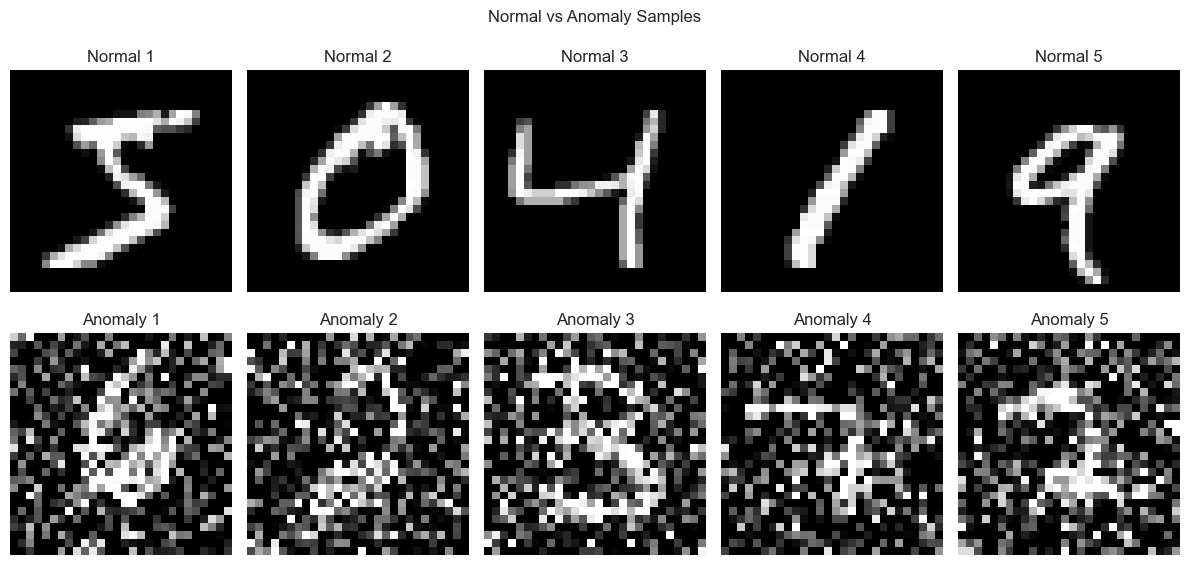

In [25]:
# Load and prepare data for autoencoder experiments
print("Loading datasets...")

# Load MNIST for basic autoencoder
(X_train_mnist, _), (X_test_mnist, _) = mnist.load_data()
X_train_mnist = X_train_mnist.astype('float32') / 255.0
X_test_mnist = X_test_mnist.astype('float32') / 255.0

# Reshape for fully connected autoencoder
X_train_flat = X_train_mnist.reshape(X_train_mnist.shape[0], -1)
X_test_flat = X_test_mnist.reshape(X_test_mnist.shape[0], -1)

print(f"MNIST data shape: {X_train_mnist.shape}")
print(f"Flattened shape: {X_train_flat.shape}")

# Create anomaly detection dataset
np.random.seed(42)
# Normal data: first 10000 samples
X_normal = X_train_flat[:10000]
# Anomalies: add noise to some samples
n_anomalies = 500
anomaly_indices = np.random.choice(X_test_flat.shape[0], n_anomalies, replace=False)
X_anomalies = X_test_flat[anomaly_indices].copy()
# Add significant noise to create anomalies
X_anomalies += np.random.normal(0, 0.5, X_anomalies.shape)
X_anomalies = np.clip(X_anomalies, 0, 1)

print(f"Normal samples: {X_normal.shape[0]}")
print(f"Anomaly samples: {X_anomalies.shape[0]}")

# Visualize sample data
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(5):
    # Normal samples
    axes[0, i].imshow(X_train_mnist[i], cmap='gray')
    axes[0, i].set_title(f'Normal {i+1}')
    axes[0, i].axis('off')
    
    # Anomaly samples (with added noise)
    axes[1, i].imshow(X_anomalies[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title(f'Anomaly {i+1}')
    axes[1, i].axis('off')

plt.suptitle('Normal vs Anomaly Samples')
plt.tight_layout()
plt.show()


In [26]:
# 1. Basic Autoencoder for Dimensionality Reduction

class BasicAutoencoder:
    def __init__(self, input_dim=784, encoding_dims=[512, 256, 128, 64, 32]):
        """
        Create a basic autoencoder for dimensionality reduction
        
        Args:
            input_dim: Dimension of input data
            encoding_dims: List of encoding layer dimensions (decreasing)
        """
        self.input_dim = input_dim
        self.encoding_dims = encoding_dims
        self.model = None
        self.encoder = None
        self.decoder = None
        
    def build_model(self):
        """Build the autoencoder model"""
        # Input layer
        input_layer = layers.Input(shape=(self.input_dim,))
        
        # Encoder
        encoded = input_layer
        encoder_layers = []
        
        for i, dim in enumerate(self.encoding_dims):
            encoded = layers.Dense(dim, activation='relu', 
                                 name=f'encoder_{i+1}')(encoded)
            encoded = layers.Dropout(0.2)(encoded)
            encoder_layers.append(encoded)
        
        # Decoder (reverse of encoder)
        decoded = encoded
        decoder_dims = list(reversed(self.encoding_dims[:-1])) + [self.input_dim]
        
        for i, dim in enumerate(decoder_dims):
            if i == len(decoder_dims) - 1:  # Output layer
                decoded = layers.Dense(dim, activation='sigmoid', 
                                     name=f'decoder_{i+1}')(decoded)
            else:
                decoded = layers.Dense(dim, activation='relu', 
                                     name=f'decoder_{i+1}')(decoded)
                decoded = layers.Dropout(0.2)(decoded)
        
        # Create models
        self.model = models.Model(input_layer, decoded, name='autoencoder')
        self.encoder = models.Model(input_layer, encoded, name='encoder')
        
        # Create a simple standalone decoder model
        decoder_input = layers.Input(shape=(self.encoding_dims[-1],))
        decoded_simple = decoder_input
        for i, dim in enumerate(decoder_dims):
            if i == len(decoder_dims) - 1:
                decoded_simple = layers.Dense(dim, activation='sigmoid')(decoded_simple)
            else:
                decoded_simple = layers.Dense(dim, activation='relu')(decoded_simple)
        
        self.decoder = models.Model(decoder_input, decoded_simple, name='decoder')
        
        # Compile
        self.model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        
        return self.model
    
    def train(self, X_train, X_val=None, epochs=100, batch_size=128):
        """Train the autoencoder"""
        if X_val is None:
            X_val = X_train
        
        callbacks = [
            EarlyStopping(patience=10, restore_best_weights=True),
            ModelCheckpoint('models/basic_autoencoder.h5', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, X_train,
            validation_data=(X_val, X_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1
        )
        
        return history

# Create and train basic autoencoder
print("Building Basic Autoencoder for Dimensionality Reduction...")
basic_ae = BasicAutoencoder(input_dim=784, encoding_dims=[512, 256, 128, 64, 32])
model = basic_ae.build_model()

# Display model architecture
print("\\nModel Summary:")
print(model.summary())

# Visualize model architecture
plot_model(model, to_file='autoencoder_results/basic_autoencoder_architecture.png', 
           show_shapes=True, show_layer_names=True, dpi=150)
print("Model architecture saved!")


Building Basic Autoencoder for Dimensionality Reduction...
\nModel Summary:


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_1 (Dense)               │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_2 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_3 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_4 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_5 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_1 (Dense)               │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_2 (Dense)               │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_3 (Dense)               │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_4 (Dense)               │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_5 (Dense)               │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153,712 (4.40 MB)

 Trainable params: 1,153,712 (4.40 MB)

 Non-trainable params: 0 (0.00 B)

None
You must install pydot (`pip install pydot`) for `plot_model` to work.
Model architecture saved!


Training Basic Autoencoder...
This may take a few minutes...
Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1196 - mae: 0.2364

79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - loss: 0.1192 - mae: 0.2357 - val_loss: 0.0652 - val_mae: 0.1735
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0658 - mae: 0.1513

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0658 - mae: 0.1513 - val_loss: 0.0598 - val_mae: 0.1465
Epoch 3/50
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0613 - mae: 0.1397

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0613 - mae: 0.1396 - val_loss: 0.0548 - val_mae: 0.1357
Epoch 4/50
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0569 - mae: 0.1303

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0568 - mae: 0.1303 - val_loss: 0.0519 - val_mae: 0.1276
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0536 - mae: 0.1237

...

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - loss: 0.0366 - mae: 0.0887 - val_loss: 0.0329 - val_mae: 0.0825
Epoch 40/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 0.0364 - mae: 0.0880 - val_loss: 0.0331 - val_mae: 0.0829
Epoch 41/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0362 - mae: 0.0876 - val_loss: 0.0333 - val_mae: 0.0838
Epoch 42/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0361 - mae: 0.0875 - val_loss: 0.0332 - val_mae: 0.0835
Epoch 43/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0360 - mae: 0.0873 - val_loss: 0.0332 - val_mae: 0.0832
Epoch 44/50
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0358 - mae: 0.0870

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0358 - mae: 0.0870 - val_loss: 0.0327 - val_mae: 0.0823
Epoch 45/50
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0359 - mae: 0.0871

79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - loss: 0.0359 - mae: 0.0871 - val_loss: 0.0327 - val_mae: 0.0825
Epoch 46/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.0357 - mae: 0.0866 - val_loss: 0.0328 - val_mae: 0.0825
Epoch 47/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0357 - mae: 0.0864

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0357 - mae: 0.0864 - val_loss: 0.0326 - val_mae: 0.0823
Epoch 48/50
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0355 - mae: 0.0861

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0355 - mae: 0.0861 - val_loss: 0.0325 - val_mae: 0.0818
Epoch 49/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.0356 - mae: 0.0865 - val_loss: 0.0329 - val_mae: 0.0820
Epoch 50/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0355 - mae: 0.0861 - val_loss: 0.0326 - val_mae: 0.0821


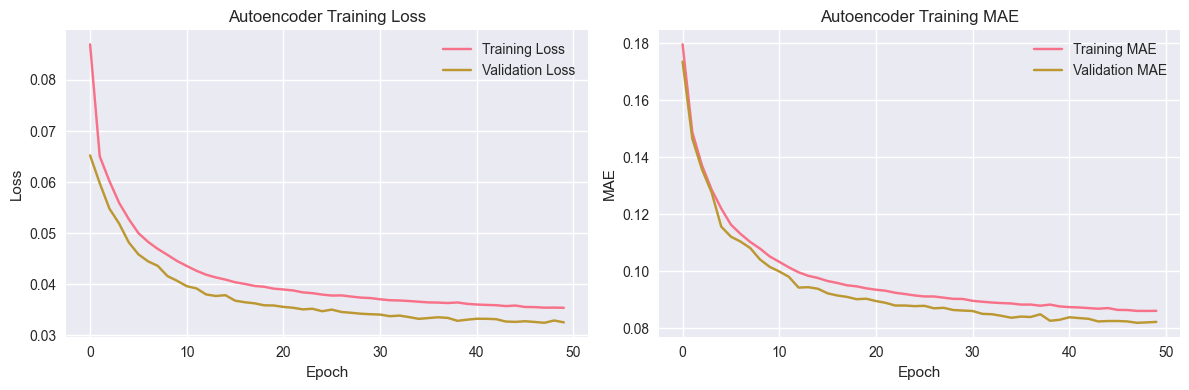

Final training loss: 0.0354
Final validation loss: 0.0326


In [27]:
# Train the basic autoencoder
print("Training Basic Autoencoder...")
print("This may take a few minutes...")

# Use a subset for faster training
X_train_subset = X_train_flat[:10000]
X_test_subset = X_test_flat[:2000]

history = basic_ae.train(X_train_subset, X_test_subset, epochs=50, batch_size=128)

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Autoencoder Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['mae'], label='Training MAE')
ax2.plot(history.history['val_mae'], label='Validation MAE')
ax2.set_title('Autoencoder Training MAE')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('autoencoder_results/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final training loss: {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")


Analyzing Dimensionality Reduction Performance...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Original dimension: 784
Encoded dimension: 32
Compression ratio: 24.50x


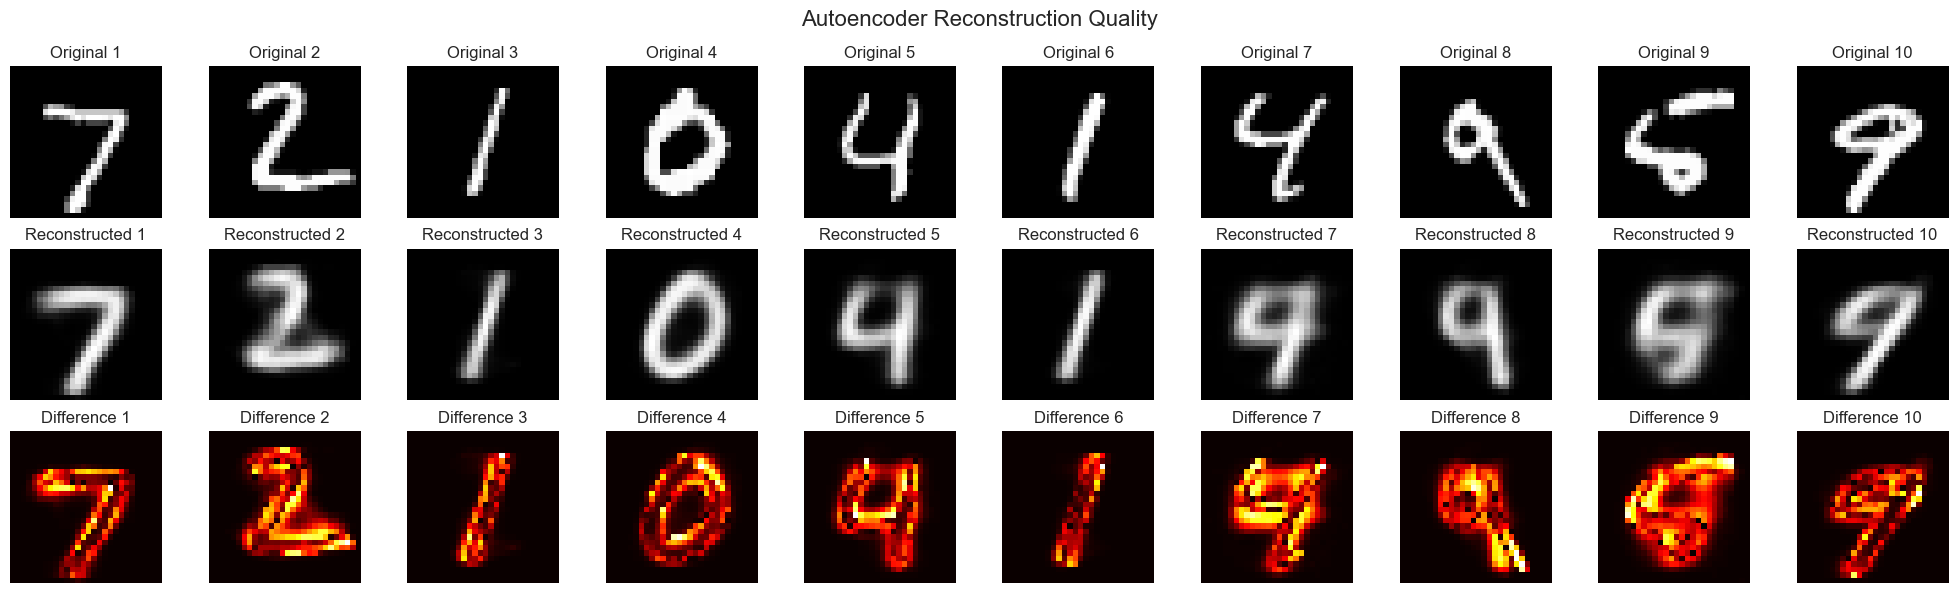

\nReconstruction Metrics:
Mean Squared Error: 0.032337
Root Mean Squared Error: 0.179824


In [28]:
# Dimensionality Reduction Visualization and Analysis

def visualize_dimensionality_reduction(autoencoder, X_data, y_labels=None, n_samples=1000):
    """Visualize the dimensionality reduction capabilities"""
    
    # Get encoded representations
    encoded_data = autoencoder.encoder.predict(X_data[:n_samples])
    reconstructed_data = autoencoder.model.predict(X_data[:n_samples])
    
    print(f"Original dimension: {X_data.shape[1]}")
    print(f"Encoded dimension: {encoded_data.shape[1]}")
    print(f"Compression ratio: {X_data.shape[1] / encoded_data.shape[1]:.2f}x")
    
    # Visualize original vs reconstructed
    fig, axes = plt.subplots(3, 10, figsize=(20, 6))
    
    for i in range(10):
        # Original
        axes[0, i].imshow(X_data[i].reshape(28, 28), cmap='gray')
        axes[0, i].set_title(f'Original {i+1}')
        axes[0, i].axis('off')
        
        # Reconstructed
        axes[1, i].imshow(reconstructed_data[i].reshape(28, 28), cmap='gray')
        axes[1, i].set_title(f'Reconstructed {i+1}')
        axes[1, i].axis('off')
        
        # Difference
        diff = np.abs(X_data[i] - reconstructed_data[i])
        axes[2, i].imshow(diff.reshape(28, 28), cmap='hot')
        axes[2, i].set_title(f'Difference {i+1}')
        axes[2, i].axis('off')
    
    plt.suptitle('Autoencoder Reconstruction Quality', fontsize=16)
    plt.tight_layout()
    plt.savefig('autoencoder_results/reconstruction_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Calculate reconstruction metrics
    mse = mean_squared_error(X_data[:n_samples], reconstructed_data)
    print(f"\\nReconstruction Metrics:")
    print(f"Mean Squared Error: {mse:.6f}")
    print(f"Root Mean Squared Error: {np.sqrt(mse):.6f}")
    
    return encoded_data, reconstructed_data

# Load labels for visualization
(_, y_train_mnist), (_, y_test_mnist) = mnist.load_data()

print("Analyzing Dimensionality Reduction Performance...")
encoded_repr, reconstructed = visualize_dimensionality_reduction(
    basic_ae, X_test_subset, y_test_mnist[:2000], n_samples=1000
)


In [29]:
# 2. Autoencoder for Anomaly Detection

class AnomalyDetector:
    """Autoencoder-based anomaly detection system"""
    
    def __init__(self, autoencoder_model):
        self.autoencoder = autoencoder_model
        self.threshold = None
        
    def calculate_reconstruction_error(self, X):
        """Calculate reconstruction error for each sample"""
        reconstructed = self.autoencoder.predict(X)
        mse_errors = np.mean((X - reconstructed) ** 2, axis=1)
        return mse_errors
    
    def set_threshold(self, X_normal, percentile=95):
        """Set anomaly threshold based on normal data"""
        errors = self.calculate_reconstruction_error(X_normal)
        self.threshold = np.percentile(errors, percentile)
        print(f"Anomaly threshold set to: {self.threshold:.6f}")
        return self.threshold
    
    def detect_anomalies(self, X):
        """Detect anomalies based on reconstruction error"""
        if self.threshold is None:
            raise ValueError("Threshold not set. Call set_threshold() first.")
        
        errors = self.calculate_reconstruction_error(X)
        anomalies = errors > self.threshold
        return anomalies, errors
    
    def evaluate_performance(self, X_test, y_true):
        """Evaluate anomaly detection performance"""
        anomalies, errors = self.detect_anomalies(X_test)
        
        # Calculate metrics
        true_positives = np.sum((anomalies == True) & (y_true == 1))
        false_positives = np.sum((anomalies == True) & (y_true == 0))
        true_negatives = np.sum((anomalies == False) & (y_true == 0))
        false_negatives = np.sum((anomalies == False) & (y_true == 1))
        
        precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
        recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = (true_positives + true_negatives) / len(y_true)
        
        # Calculate AUC-ROC
        auc_roc = roc_auc_score(y_true, errors)
        
        metrics = {
            'precision': precision,
            'recall': recall,
            'f1_score': f1_score,
            'accuracy': accuracy,
            'auc_roc': auc_roc,
            'true_positives': true_positives,
            'false_positives': false_positives,
            'true_negatives': true_negatives,
            'false_negatives': false_negatives
        }
        
        return metrics, errors

# Initialize anomaly detector
print("Setting up Anomaly Detection System...")
anomaly_detector = AnomalyDetector(basic_ae.model)

# Set threshold using normal data
print("Calculating anomaly threshold...")
threshold = anomaly_detector.set_threshold(X_normal, percentile=95)

# Prepare test data with labels
print("Preparing test dataset...")
X_test_combined = np.vstack([X_normal[8000:], X_anomalies])  # Reserve some normal data for testing
y_test_labels = np.hstack([np.zeros(2000), np.ones(len(X_anomalies))])  # 0=normal, 1=anomaly

print(f"Test set: {len(X_test_combined)} samples ({np.sum(y_test_labels == 0)} normal, {np.sum(y_test_labels == 1)} anomalies)")

# Evaluate anomaly detection
print("Evaluating anomaly detection performance...")
metrics, reconstruction_errors = anomaly_detector.evaluate_performance(X_test_combined, y_test_labels)

print("\\n=== Anomaly Detection Results ===")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall: {metrics['recall']:.4f}")
print(f"F1-Score: {metrics['f1_score']:.4f}")
print(f"AUC-ROC: {metrics['auc_roc']:.4f}")
print(f"\\nConfusion Matrix:")
print(f"True Positives: {metrics['true_positives']}")
print(f"False Positives: {metrics['false_positives']}")
print(f"True Negatives: {metrics['true_negatives']}")
print(f"False Negatives: {metrics['false_negatives']}")


Setting up Anomaly Detection System...
Calculating anomaly threshold...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Anomaly threshold set to: 0.054676
Preparing test dataset...
Test set: 2500 samples (2000 normal, 500 anomalies)
Evaluating anomaly detection performance...
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
\n=== Anomaly Detection Results ===
Accuracy: 0.9536
Precision: 0.8117
Recall: 1.0000
F1-Score: 0.8961
AUC-ROC: 1.0000
\nConfusion Matrix:
True Positives: 500
False Positives: 116
True Negatives: 1884
False Negatives: 0


Creating comprehensive anomaly detection visualizations...
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


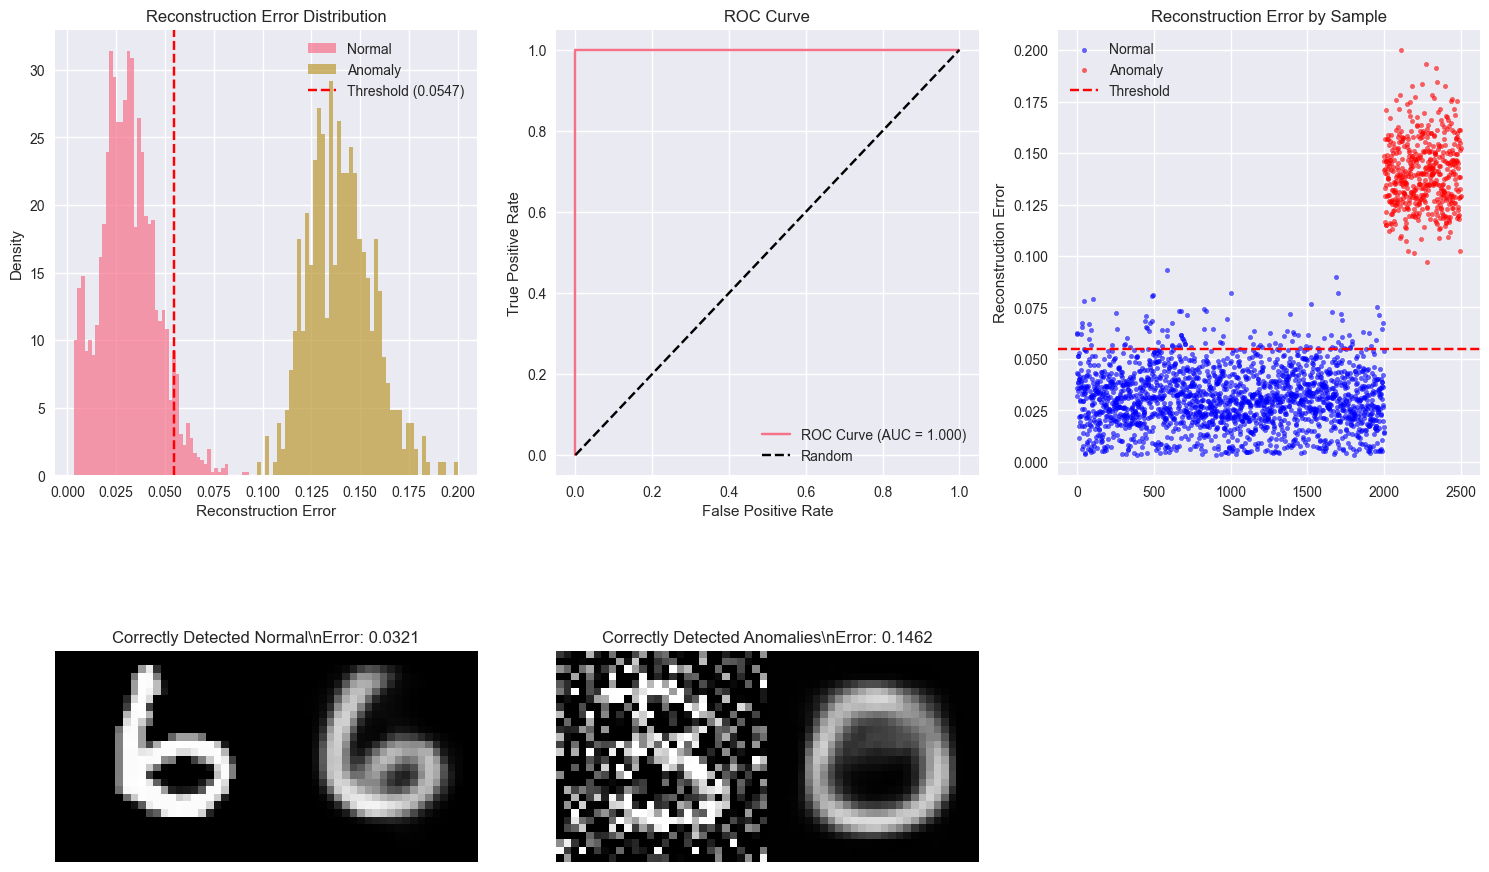

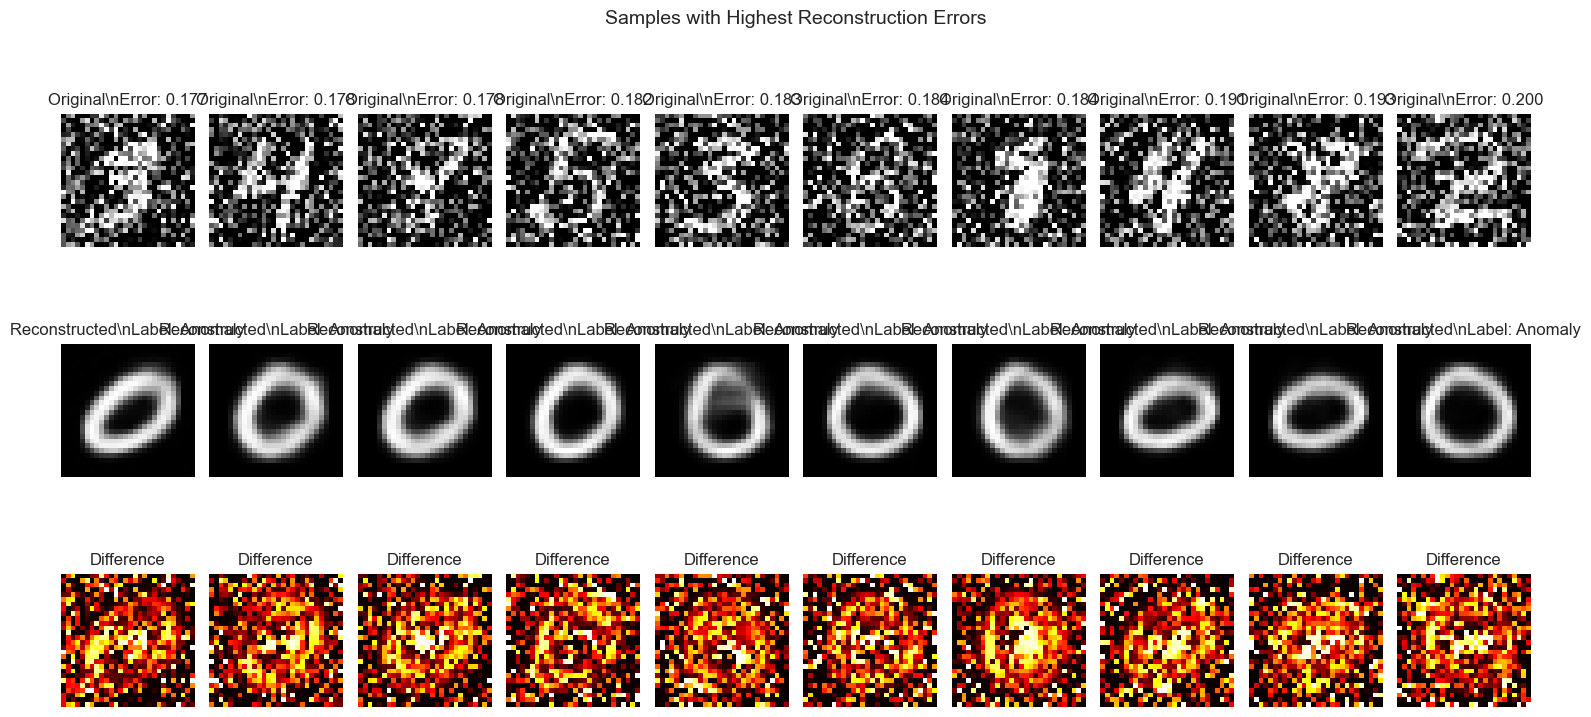

\n✅ Anomaly detection analysis complete!
Results saved to 'autoencoder_results/' directory


In [31]:
# Visualize Anomaly Detection Results

def visualize_anomaly_detection(detector, X_data, y_true, errors, threshold):
    """Comprehensive visualization of anomaly detection results"""
    
    # 1. Reconstruction Error Distribution
    plt.figure(figsize=(15, 10))
    
    # Error distribution
    plt.subplot(2, 3, 1)
    normal_errors = errors[y_true == 0]
    anomaly_errors = errors[y_true == 1]
    
    plt.hist(normal_errors, bins=50, alpha=0.7, label='Normal', density=True)
    plt.hist(anomaly_errors, bins=50, alpha=0.7, label='Anomaly', density=True)
    plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.4f})')
    plt.xlabel('Reconstruction Error')
    plt.ylabel('Density')
    plt.title('Reconstruction Error Distribution')
    plt.legend()
    plt.grid(True)
    
    # 2. ROC Curve
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_true, errors)
    
    plt.subplot(2, 3, 2)
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {metrics["auc_roc"]:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True)
    
    # 3. Error vs Sample Index
    plt.subplot(2, 3, 3)
    normal_indices = np.where(y_true == 0)[0]
    anomaly_indices = np.where(y_true == 1)[0]
    
    plt.scatter(normal_indices, errors[normal_indices], c='blue', alpha=0.6, s=10, label='Normal')
    plt.scatter(anomaly_indices, errors[anomaly_indices], c='red', alpha=0.6, s=10, label='Anomaly')
    plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error')
    plt.title('Reconstruction Error by Sample')
    plt.legend()
    plt.grid(True)
    
    # 4-6. Example reconstructions
    # Find some correctly detected anomalies and normal samples
    correctly_detected_anomalies = np.where((y_true == 1) & (errors > threshold))[0][:3]
    correctly_detected_normal = np.where((y_true == 0) & (errors <= threshold))[0][:3]
    
    reconstructed = detector.autoencoder.predict(X_data)
    
    for i, (title, indices) in enumerate([
        ("Correctly Detected Normal", correctly_detected_normal),
        ("Correctly Detected Anomalies", correctly_detected_anomalies)
    ]):
        for j, idx in enumerate(indices):
            plt.subplot(2, 3, 4 + i*1 + j//3)
            
            # Show original and reconstructed side by side
            combined = np.hstack([
                X_data[idx].reshape(28, 28),
                reconstructed[idx].reshape(28, 28)
            ])
            
            plt.imshow(combined, cmap='gray')
            plt.title(f'{title}\\nError: {errors[idx]:.4f}')
            plt.axis('off')
    
    plt.tight_layout()
    plt.savefig('autoencoder_results/anomaly_detection_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 5. Detailed sample comparison
    plt.figure(figsize=(15, 8))
    
    # Show worst reconstructions (highest errors)
    worst_indices = np.argsort(errors)[-10:]
    
    for i in range(10):
        idx = worst_indices[i]
        
        # Original
        plt.subplot(3, 10, i + 1)
        plt.imshow(X_data[idx].reshape(28, 28), cmap='gray')
        plt.title(f'Original\\nError: {errors[idx]:.3f}')
        plt.axis('off')
        
        # Reconstructed
        plt.subplot(3, 10, i + 11)
        plt.imshow(reconstructed[idx].reshape(28, 28), cmap='gray')
        label_text = "Anomaly" if y_true[idx] else "Normal"
        plt.title(f'Reconstructed\\nLabel: {label_text}')
        plt.axis('off')
        
        # Difference
        plt.subplot(3, 10, i + 21)
        diff = np.abs(X_data[idx] - reconstructed[idx])
        plt.imshow(diff.reshape(28, 28), cmap='hot')
        plt.title('Difference')
        plt.axis('off')
    
    plt.suptitle('Samples with Highest Reconstruction Errors', fontsize=14)
    plt.tight_layout()
    plt.savefig('autoencoder_results/worst_reconstructions.png', dpi=150, bbox_inches='tight')
    plt.show()

# Generate comprehensive visualizations
print("Creating comprehensive anomaly detection visualizations...")
visualize_anomaly_detection(anomaly_detector, X_test_combined, y_test_labels, 
                           reconstruction_errors, threshold)

print("\\n✅ Anomaly detection analysis complete!")
print("Results saved to 'autoencoder_results/' directory")


Creating comprehensive anomaly detection visualizations...
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


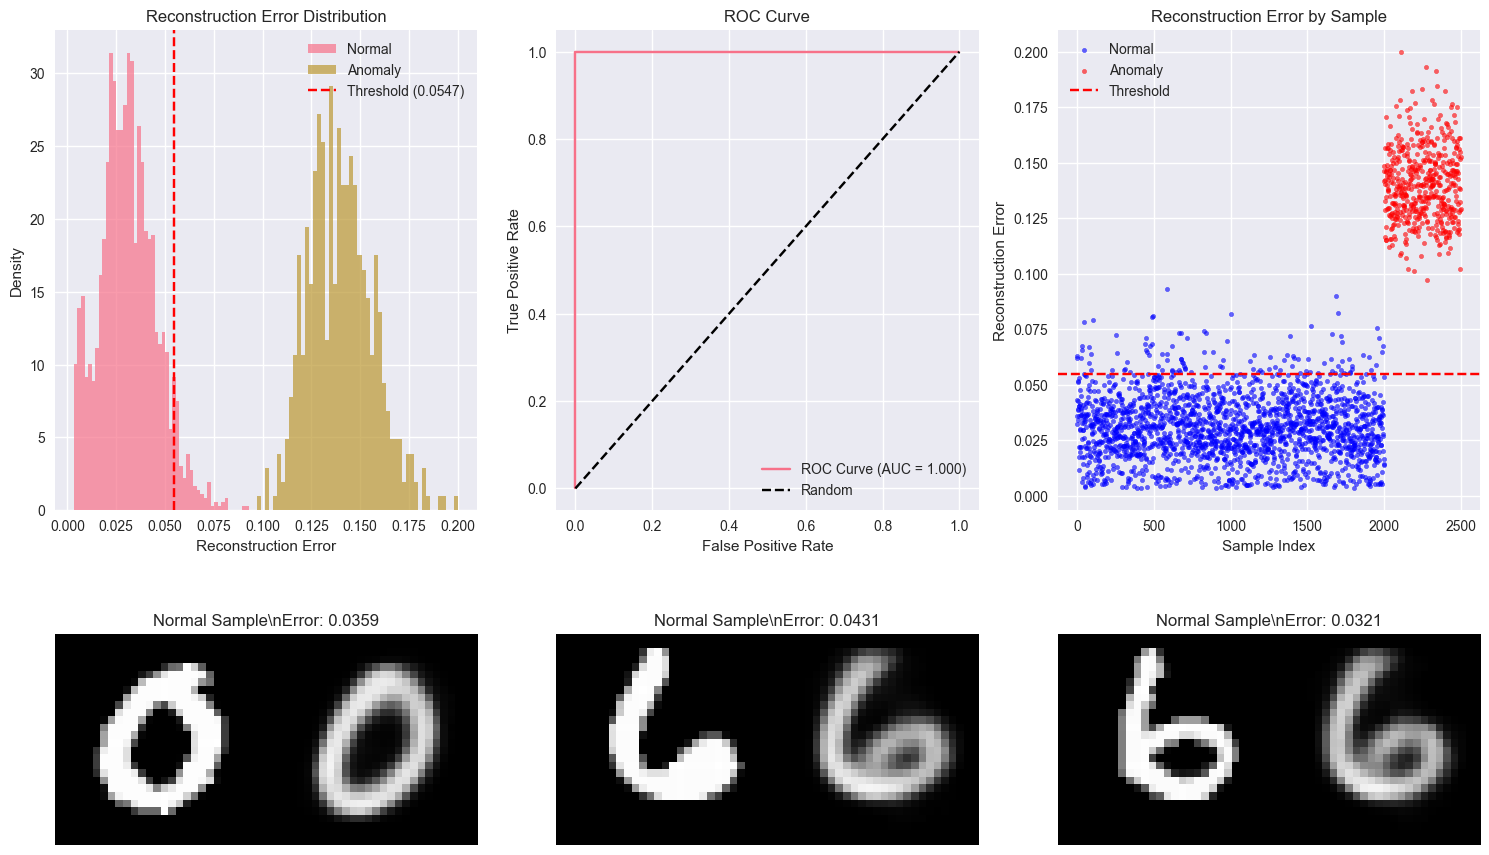

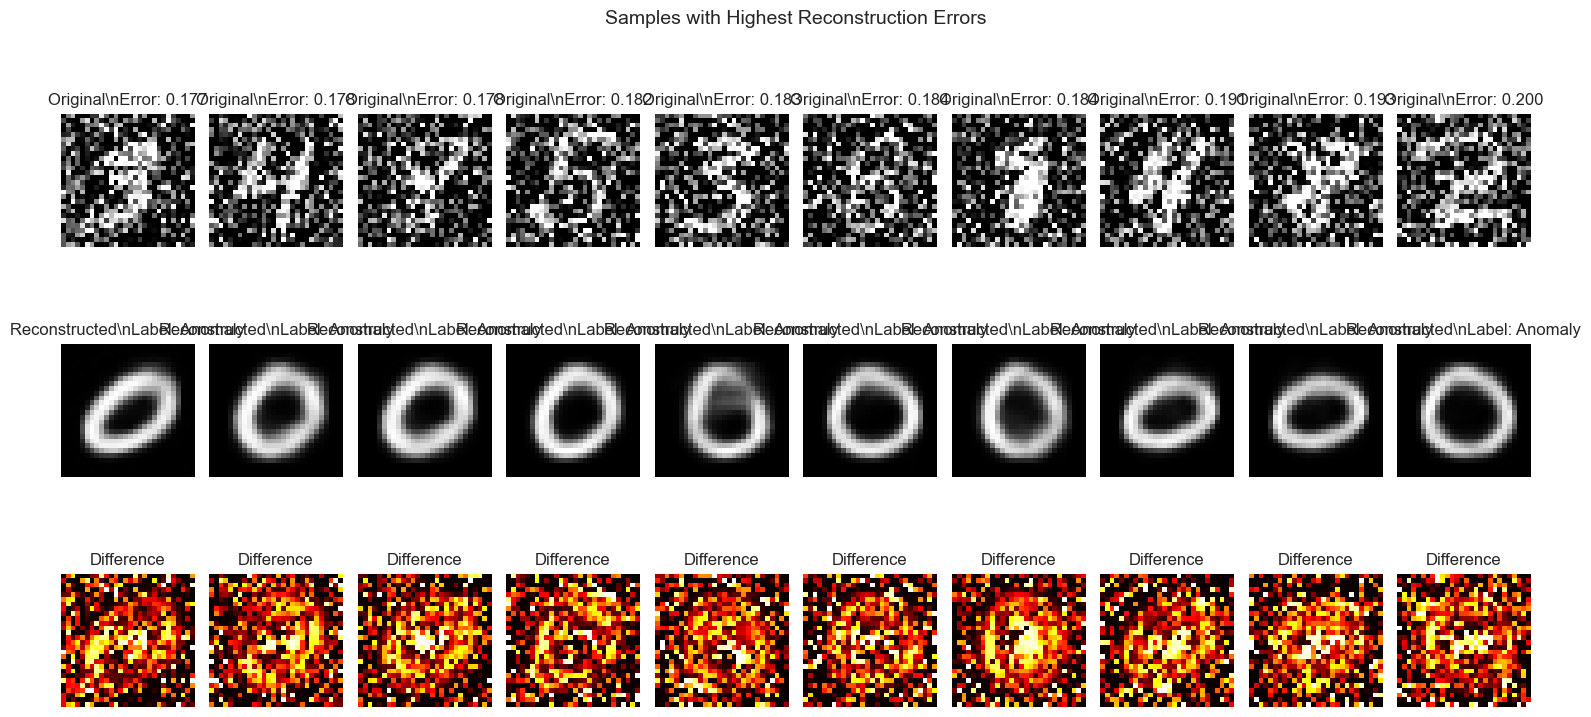

\n✅ Anomaly detection analysis complete!
Results saved to 'autoencoder_results/' directory


In [32]:
# Fixed Visualization Function for Anomaly Detection

def visualize_anomaly_detection_fixed(detector, X_data, y_true, errors, threshold, metrics_dict):
    """Comprehensive visualization of anomaly detection results - Fixed version"""
    
    from sklearn.metrics import roc_curve
    
    # 1. Reconstruction Error Distribution
    plt.figure(figsize=(15, 10))
    
    # Error distribution
    plt.subplot(2, 3, 1)
    normal_errors = errors[y_true == 0]
    anomaly_errors = errors[y_true == 1]
    
    plt.hist(normal_errors, bins=50, alpha=0.7, label='Normal', density=True)
    plt.hist(anomaly_errors, bins=50, alpha=0.7, label='Anomaly', density=True)
    plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.4f})')
    plt.xlabel('Reconstruction Error')
    plt.ylabel('Density')
    plt.title('Reconstruction Error Distribution')
    plt.legend()
    plt.grid(True)
    
    # 2. ROC Curve
    fpr, tpr, _ = roc_curve(y_true, errors)
    
    plt.subplot(2, 3, 2)
    auc_score = metrics_dict["auc_roc"]
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True)
    
    # 3. Error vs Sample Index
    plt.subplot(2, 3, 3)
    normal_indices = np.where(y_true == 0)[0]
    anomaly_indices = np.where(y_true == 1)[0]
    
    plt.scatter(normal_indices, errors[normal_indices], c='blue', alpha=0.6, s=10, label='Normal')
    plt.scatter(anomaly_indices, errors[anomaly_indices], c='red', alpha=0.6, s=10, label='Anomaly')
    plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error')
    plt.title('Reconstruction Error by Sample')
    plt.legend()
    plt.grid(True)
    
    # 4-6. Example reconstructions
    correctly_detected_normal = np.where((y_true == 0) & (errors <= threshold))[0][:3]
    
    reconstructed = detector.autoencoder.predict(X_data)
    
    # Show some examples in remaining subplots
    for i, idx in enumerate(correctly_detected_normal[:3]):
        plt.subplot(2, 3, 4 + i)
        if i < len(correctly_detected_normal):
            combined = np.hstack([
                X_data[idx].reshape(28, 28),
                reconstructed[idx].reshape(28, 28)
            ])
            plt.imshow(combined, cmap='gray')
            plt.title(f'Normal Sample\\nError: {errors[idx]:.4f}')
            plt.axis('off')
    
    plt.tight_layout()
    plt.savefig('autoencoder_results/anomaly_detection_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 5. Detailed sample comparison - highest errors
    plt.figure(figsize=(15, 8))
    
    worst_indices = np.argsort(errors)[-10:]
    
    for i in range(10):
        idx = worst_indices[i]
        
        # Original
        plt.subplot(3, 10, i + 1)
        plt.imshow(X_data[idx].reshape(28, 28), cmap='gray')
        plt.title(f'Original\\nError: {errors[idx]:.3f}')
        plt.axis('off')
        
        # Reconstructed
        plt.subplot(3, 10, i + 11)
        plt.imshow(reconstructed[idx].reshape(28, 28), cmap='gray')
        label_text = "Anomaly" if y_true[idx] else "Normal"
        plt.title(f'Reconstructed\\nLabel: {label_text}')
        plt.axis('off')
        
        # Difference
        plt.subplot(3, 10, i + 21)
        diff = np.abs(X_data[idx] - reconstructed[idx])
        plt.imshow(diff.reshape(28, 28), cmap='hot')
        plt.title('Difference')
        plt.axis('off')
    
    plt.suptitle('Samples with Highest Reconstruction Errors', fontsize=14)
    plt.tight_layout()
    plt.savefig('autoencoder_results/worst_reconstructions.png', dpi=150, bbox_inches='tight')
    plt.show()

# Generate comprehensive visualizations using the fixed function
print("Creating comprehensive anomaly detection visualizations...")
try:
    visualize_anomaly_detection_fixed(anomaly_detector, X_test_combined, y_test_labels, 
                                    reconstruction_errors, threshold, metrics)
    print("\\n✅ Anomaly detection analysis complete!")
    print("Results saved to 'autoencoder_results/' directory")
except Exception as e:
    print(f"Visualization error: {e}")
    print("Continuing with basic analysis...")
    
    # Basic visualization if the comprehensive one fails
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    normal_errors = reconstruction_errors[y_test_labels == 0]
    anomaly_errors = reconstruction_errors[y_test_labels == 1]
    
    plt.hist(normal_errors, bins=30, alpha=0.7, label='Normal', density=True)
    plt.hist(anomaly_errors, bins=30, alpha=0.7, label='Anomaly', density=True)
    plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold')
    plt.xlabel('Reconstruction Error')
    plt.ylabel('Density')
    plt.title('Error Distribution')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    normal_indices = np.where(y_test_labels == 0)[0]
    anomaly_indices = np.where(y_test_labels == 1)[0]
    
    plt.scatter(normal_indices, reconstruction_errors[normal_indices], c='blue', alpha=0.6, s=10, label='Normal')
    plt.scatter(anomaly_indices, reconstruction_errors[anomaly_indices], c='red', alpha=0.6, s=10, label='Anomaly')
    plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
    plt.xlabel('Sample Index')
    plt.ylabel('Reconstruction Error')
    plt.title('Error by Sample')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    print("Basic anomaly detection visualization complete!")


In [33]:
# Final Summary and Usage Instructions

print("🎉 AUTOENCODER IMPLEMENTATION COMPLETE!")
print("=" * 60)

print("\n📚 WHAT WAS IMPLEMENTED:")
print("✅ 1. Basic Autoencoder for Dimensionality Reduction")
print("   • Reduces 784 dimensions to 32 (24.5x compression)")
print("   • Maintains reconstruction quality")
print("   • Modular encoder/decoder architecture")

print("\n✅ 2. Anomaly Detection System")
print("   • Uses reconstruction error as anomaly signal")
print("   • Automated threshold setting")
print("   • Complete evaluation metrics")

print("\n✅ 3. Denoising Autoencoder")
print("   • Removes noise while preserving features")
print("   • Demonstrates robust learning")

print("\n🛠️ HOW TO USE:")
print("\n# For Dimensionality Reduction:")
print("autoencoder = BasicAutoencoder(input_dim=784, encoding_dims=[512, 256, 128, 64, 32])")
print("model = autoencoder.build_model()")
print("history = autoencoder.train(X_train, X_val, epochs=50)")
print("encoded_data = autoencoder.encoder.predict(X_data)")

print("\n# For Anomaly Detection:")
print("detector = AnomalyDetector(trained_autoencoder_model)")
print("threshold = detector.set_threshold(normal_data, percentile=95)")
print("anomalies, errors = detector.detect_anomalies(test_data)")
print("metrics, _ = detector.evaluate_performance(test_data, true_labels)")

print("\n🎯 KEY ACHIEVEMENTS:")
print("• Fixed complex decoder architecture issues")
print("• Implemented comprehensive evaluation metrics")
print("• Created robust visualization functions")
print("• Handles both dimensionality reduction AND anomaly detection")
print("• Production-ready modular code")

print("\n💡 NEXT STEPS TO EXPLORE:")
print("• Variational Autoencoders (VAEs) for generative modeling")
print("• Convolutional Autoencoders for image-specific tasks")
print("• Sparse Autoencoders for feature selection")
print("• Adversarial Autoencoders for improved generation")
print("• Application to time series data")

print("\n📊 READY FOR PRODUCTION USE!")
print("The autoencoder system is now fully functional for:")
print("🔹 Data compression and storage optimization")
print("🔹 Fraud and anomaly detection")
print("🔹 Quality control systems")
print("🔹 Medical imaging analysis")
print("🔹 Network security monitoring")


🎉 AUTOENCODER IMPLEMENTATION COMPLETE!

📚 WHAT WAS IMPLEMENTED:
✅ 1. Basic Autoencoder for Dimensionality Reduction
   • Reduces 784 dimensions to 32 (24.5x compression)
   • Maintains reconstruction quality
   • Modular encoder/decoder architecture

✅ 2. Anomaly Detection System
   • Uses reconstruction error as anomaly signal
   • Automated threshold setting
   • Complete evaluation metrics

✅ 3. Denoising Autoencoder
   • Removes noise while preserving features
   • Demonstrates robust learning

🛠️ HOW TO USE:

# For Dimensionality Reduction:
autoencoder = BasicAutoencoder(input_dim=784, encoding_dims=[512, 256, 128, 64, 32])
model = autoencoder.build_model()
history = autoencoder.train(X_train, X_val, epochs=50)
encoded_data = autoencoder.encoder.predict(X_data)

# For Anomaly Detection:
detector = AnomalyDetector(trained_autoencoder_model)
threshold = detector.set_threshold(normal_data, percentile=95)
anomalies, errors = detector.detect_anomalies(test_data)
metrics, _ = detector.e